In [14]:
import numpy as np
import pandas as pd
import scipy.io
import matplotlib.pyplot as plt
import seaborn as sns
import scikit_posthocs as sp
from itertools import combinations

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

import neurokit2 as nk
# import pyPPG as ppg

from scipy.stats import kruskal, mannwhitneyu

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict, LeaveOneOut
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, balanced_accuracy_score
from sklearn.ensemble import RandomForestClassifier

from Participant import Participant

import preprocessing as pp

### This is an interactive tour over the signal processing and emotion classification pipeline
After chosing a participant's ID, some demographics and questionnaire data is printed. <br>
Afterwards an experimental condition ('image-only' or 'audio+image') is chosen, <br>
and as a first approach, an emotion pair for binary classification ('Happiness', 'Sadness' or 'Anger') is chosen as well. <br>
Sidenote: The experimental condition 'audio-only' was previously discarded from further analysis (not supported).

In [88]:
pid = 44
p = Participant(participantID=pid, rawData=True)
print(p)

| Participant Data Summary: ID 44     |

--- Demographics ---
    - Age: 24
    - Gender: Female
    - Education: High school diploma
    - Field_of_study: wirtschaftspsychologie

--- TAS-20 Scores ---
  - Difficulty Identifying Feelings (DIF): 25
  - Difficulty Describing Feelings (DDF): 19
  - Externally-Oriented Thinking (EOT):  19
  - TOTAL TAS Score:                       63

--- PANAS Scores ---
  - Positive Affect (PA): 28
  - Negative Affect (NA): 27

--- Experimental Data ---
  - Markers: DataFrame with 30 rows and 12 columns
-------------------------------------------


In [89]:
condition = 'image-only'
condition_markers = p.markers[p.markers['condition'] == condition]

In [90]:
# te1 = 'Happiness'
te1 = 'Anger'
te2 = 'Sadness'

##### Segmentation: Extract (emotion label and block specific) 2-minute recordings 

In [91]:
# Segmentation params
delta_start = -1
extra_duration = 2
# 1 second before stimulus onset, 1 second after stimulus offset

segments = {}
segments[te1] = {}
segments[te2] = {}

# markers specific to emotion response for the given condition
te1_markers = condition_markers[condition_markers['emotion_response'] == te1]
te2_markers = condition_markers[condition_markers['emotion_response'] == te2]

# segment the data based on the markers
b_i=1
for index in te1_markers.index:
    start = p.get_timestamp_from_index(index, img_idx=0)
    segments[te1][f'b{b_i}'] = p.get_rawData_from_timestamp(start, delta_start=delta_start, duration=60+extra_duration)
    b_i += 1
b_j=1
for index in te2_markers.index:
    start = p.get_timestamp_from_index(index, img_idx=0)
    segments[te2][f'b{b_j}'] = p.get_rawData_from_timestamp(start, delta_start=delta_start, duration=60+extra_duration)
    b_j += 1

# number of blocks to consider (balanced across both emotion responses)
n_blocks = max(b_i, b_j) - 1

configs = []
for i in range(1, n_blocks + 1):
    for te in [te1, te2]:
        if f'b{i}' in segments[te]:
            configs.append({'te': te, 'block': f'b{i}'})

In [92]:
assert te1_markers.__len__() == te2_markers.__len__(), "Number of markers for both emotion responses should be equal."

#####

##### PPG Preprocessing and Visualization
Methods 1 and 2 for signal cleaning are described below.

In [93]:
method = 1

In [94]:
# Method 1: Cleaning using Jerk, SQI and Peak Correction
def manual_cleaning(ppg_df, acc_df, jerk_threshold=2.0, sqi_threshold=0.91, interval_min=0.3):
    ppg_raw = ppg_df.copy()
    ppg_df = ppg_df.copy()
    ppg_df['value'] = ppg_df['value'] * -1
    acc_df = acc_df.copy()

    # Compute jerk, apply bandpass filter and threshold
    jerk_values = np.abs(pp.compute_jerk(acc_df))
    ppg_df['value'] = pp.bvp_pp(ppg_df, acc_df, bvp_fs= 64.00064849853516, acc_fs= 64.00064849853516,
              corruption_window_points=200, jerk_threshold=jerk_threshold)['bvp_processed']
    
    # Safety check: If more than 80% of the signal was masked, skip
    processed_values = ppg_df['value'].fillna(0).values
    if np.count_nonzero(processed_values) < (0.2 * len(processed_values)):
        # print(f"Warning: Signal too noisy in {te} {block}. Skipping peaks.")
        return ppg_df, jerk_values, np.zeros(len(ppg_df)), [], []
    
    # Find peaks and onsets
    # peaks_dict = nk.ppg_findpeaks(processed_values, sampling_rate=64, method='charlton',  show=False)
    try:
        peaks_dict = nk.ppg_findpeaks(processed_values, sampling_rate=64, method='charlton', show=False)
        # Check if any peaks were actually found
        if len(peaks_dict['PPG_Peaks']) < 2:
            print("Too few peaks found")
            return ppg_df, jerk_values, np.zeros(len(ppg_df)), [], []
    except Exception as e:
        print(f"Charlton find peaks failed, use neurokit")
        # peaks_dict = nk.ppg_peaks(processed_values, sampling_rate=64, method='charlton', correct_artifacts=True)[1]
        # return ppg_df, jerk_values, np.zeros(len(ppg_df)), [], []
        _, peaks_dict = neurokit_cleaning(
            ppg_df=ppg_raw, 
            sampling_rate=64
        )

    # Compute SQI and apply mask
    quality = nk.ppg_quality(ppg_df['value'].fillna(0).values, peaks_dict['PPG_Peaks'], sampling_rate=64, method='templatematch')
    low_quality_mask = quality <= sqi_threshold
    ppg_df.loc[low_quality_mask, 'value'] = np.nan

    # Fix double peaks and onsets
    info_peaks, fixed_peaks = nk.signal_fixpeaks(np.array(peaks_dict['PPG_Peaks']), sampling_rate=64, method='neurokit',show=False, interval_min=interval_min)
    print('In seconds - missed peaks:', np.array(info_peaks['missed'])/64, 'extra peaks:', np.array(info_peaks['extra'])/64)
    info_onsets, fixed_onsets = nk.signal_fixpeaks(np.array(peaks_dict['PPG_Onsets']), sampling_rate=64, method='neurokit',show=False, interval_min=interval_min)
    print('In seconds - missed onsets:', np.array(info_onsets['missed'])/64, 'extra onsets:', np.array(info_onsets['extra'])/64)

    return ppg_df, jerk_values, quality, fixed_peaks, fixed_onsets

# Method 2: Simple SQI-based Cleaning (No Jerk or Peak Correction)
def neurokit_cleaning(ppg_df, sampling_rate=64):
    ppg_signal = ppg_df['value'].fillna(0).values *-1

    ppg_cleaned = pp.bandpass_filtering_bvp(ppg_signal, cutoff_hz=[1,16])
    
    # Find peaks
    method_peaks = "charlton"
    peaks_signal, info = nk.ppg_peaks(
        ppg_cleaned, sampling_rate=sampling_rate, method=method_peaks, correct_artifacts=True, show=False
    )
    info["sampling_rate"] = sampling_rate

    # Rate computation
    rate = nk.signal_rate(info["PPG_Peaks"], sampling_rate=sampling_rate, desired_length=len(ppg_cleaned))

    # Assess signal quality
    method_quality = 'templatematch' 
    quality = nk.ppg_quality(
        ppg_cleaned,
        peaks=info["PPG_Peaks"],
        sampling_rate=sampling_rate,
        method=method_quality
    )

    # Prepare output
    signals = pd.DataFrame(
        {
            "PPG_Raw": ppg_signal,
            "PPG_Clean": ppg_cleaned,
            "PPG_Rate": rate,
            "PPG_Quality": quality,
            "PPG_Peaks": peaks_signal["PPG_Peaks"].values,
        }
    )
    return signals, info

# Feature extraction (PPG)
def consecutive_pulse_metrics(signal, complete_fiducial_points, fs=64, window_size=10):
    """
    Calculates the variance of systolic areas VSA, heart rate and T_2 for windows of consecutive pulses.
    Discards windows where pulses are not strictly consecutive (gaps found).
    Returns start and end of each pulse sequence as well
    """
    
    pulses = []
    areas = pp.systolic_area(signal, complete_fiducial_points)
    

    # Sliding window to find blocks of 10 consecutive pulses
    i = 0
    while i <= len(areas) - window_size:
        window = areas[i : i + window_size]
        
        # Check consecutiveness: 
        is_consecutive = True
        for j in range(window_size - 1):
            if window[j]['next_onset'] != window[j+1]['onset']:
                is_consecutive = False
                break
        
        if is_consecutive:
            # VSA (Variance of Systolic Areas)
            area_values = [pulse['area'] for pulse in window]
            block_variance = np.var(area_values)
            # HR (Heart Rate)
            peaks = [pulse['peak'] for pulse in window]
            # heart_rate = np.var(np.diff(peaks))
            heart_rate = np.mean(np.diff(peaks))
            # T_2
            next_onsets = [pulse['next_onset'] for pulse in window]
            t_2s = (np.array(next_onsets) - np.array(peaks)) / fs 
            t_2_mean = np.var(t_2s)

            pulses.append({
                'VSA': block_variance,
                'HR': heart_rate,
                'T_2': t_2_mean,
                'start': window[0]['onset'],
                'end': window[window_size-1]['next_onset']
            })
            i += window_size
        else:
            i += 1
    return pulses

In [95]:
fig = make_subplots(
    rows=len(configs), 
    cols=1, 
    shared_xaxes=True,
    vertical_spacing=0.05,
    subplot_titles=[f"Target Emotion: {c['te']} | Block: {c['block']}" for c in configs]
)

all_emotion_data = []
for i, config in enumerate(configs, start=1):
    te, block = config['te'], config['block']
    # if block not in segments[te]:
    #     print(f"Skipping {te} {block}: No data available.")
    #     continue
    ppg_raw = segments[te][block]['bvp'].copy()
    eda_raw=segments[te][block]['eda'].copy()
    eda_phasic=nk.eda_phasic(eda_raw['value'], sampling_rate=4, method='cvxEDA')['EDA_Phasic']
    domain = ppg_raw['timestamp'] - ppg_raw['timestamp'].values[0]
    if method == 1:
        acc_df=segments[te][block]['acc'].copy()
        ppg_df, jerk_values, quality, fixed_peaks, fixed_onsets = manual_cleaning(
            ppg_df=ppg_raw, 
            acc_df=acc_df,
            jerk_threshold=2.0, sqi_threshold=0.95, interval_min=0.3
            )
        if len(fixed_onsets) == 0:
            print(f"Skipping {te} {block}: No onsets detected (signal too noisy).")
            continue
    
        mask = ppg_df['value'].notna()
        dic_notches, fiducial_points = pp.detect_dicrotic_notch(
            np.array(ppg_df['value'].fillna(0)), fixed_peaks, fixed_onsets, fs=64, 
            window_length=6, beta = 0.01)
        ppg_df['value'] = pp.remove_baseline_onsets(ppg_df['value'].fillna(0), np.array(fixed_onsets), fs = 64)[0]
        ppg_df.loc[~mask, 'value'] = np.nan
        fiducial_points = pp.filter_incomplete_pulses(ppg_df['value'], fiducial_points)

        ppg_signal = ppg_df['value'].values
        # domain = ppg_df['timestamp']-ppg_df['timestamp'].values[0]
    elif method == 2:
        signals, info = neurokit_cleaning(
            ppg_df=ppg_raw, 
            sampling_rate=64
        )
        ppg_signal = signals['PPG_Clean'].values
        quality = signals['PPG_Quality'].values
        fixed_peaks = info['PPG_Peaks']
        fixed_onsets = info['PPG_Onsets']

        dic_notches, fiducial_points = pp.detect_dicrotic_notch(
            ppg_signal, fixed_peaks, fixed_onsets, fs=64, 
            window_length=6, beta=0.1
            )
        ppg_signal = pp.remove_baseline_onsets(ppg_signal, np.array(fixed_onsets), fs = 64)[0]
        fiducial_points = pp.filter_incomplete_pulses(ppg_signal, fiducial_points)

    window_metrics = consecutive_pulse_metrics(ppg_signal, fiducial_points, fs=64)
    for v in window_metrics:
        all_emotion_data.append({
            # 'Emotion': f"{te}_{block}",
            'Emotion': te,
            'Block': block,
            'VSA': v['VSA'],
            'HR': v['HR'],
            'T_2': v['T_2'],
            'ComEDA': nk.entropy_sample(
                eda_phasic.values[int((v['start']/64)*4):int((v['end']/64)*4)], 
                delay=1, dimension=1, tolenrance='sd'
                )[0]
        })
    
    show_legend = True if i == 1 else False

    fig.add_trace(
        go.Scatter(
            x=domain, y=ppg_signal, 
                   mode='lines', name=f'PPG',
                   line=dict(color='#1f77b4', width=1), showlegend=show_legend),
        row=i, col=1
    )

    if method == 1:
        # jerk_scaling_factor = 1/4
        # fig.add_trace(
        #     go.Scatter(x=domain, y=jerk_values * jerk_scaling_factor, 
        #             mode='lines', name=f'Jerk',
        #             line=dict(color='#ff7f0e', width=1), showlegend=show_legend),
        #     row=i, col=1
        # )
        fig.add_trace(
            go.Scatter(x=eda_raw['timestamp'] - eda_raw['timestamp'].values[0] , y=pp.normalize(eda_phasic), 
                    mode='lines', name=f'EDA',
                    line=dict(color="#0e8fff", width=1), showlegend=show_legend),
            row=i, col=1
        )

    # quality_scaling_factor = 1/15 if ppg_signal.max() > 0.01 else 1/50
    quality_scaling_factor = 1

    fig.add_trace(
        go.Scatter(x=domain, y=quality * quality_scaling_factor, 
                   mode='lines', name=f'SQI',
                   line=dict(color="#9e704a", width=1), showlegend=show_legend),
        row=i, col=1
    )

    fig.add_trace(
        go.Scatter(x=domain, y=quality*0 + 0.91 * quality_scaling_factor, 
                   mode='lines', name=f'Min SQI',
                   line=dict(color="#7d7a78", width=1), showlegend=show_legend),
        row=i, col=1
    )

    fig.add_trace(
        go.Scatter(
            x = np.array(fixed_peaks)/64,
            y=ppg_signal[fixed_peaks],
            mode='markers', 
            name='Peaks',
            marker=dict(color='red', size=6, symbol='triangle-up'),
            showlegend=show_legend
        ),
        row=i, col=1
    )

    fig.add_trace(
        go.Scatter(
            x = np.array(fixed_onsets)/64,
            y=ppg_signal[fixed_onsets],
            mode='markers', 
            name='Onsets',
            marker=dict(color='blue', size=6, symbol='triangle-down'),
            showlegend=show_legend
        ),
        row=i, col=1
    )

    fig.add_trace(
        go.Scatter(
            x = np.array(dic_notches)/64,
            y=ppg_signal[dic_notches],
            mode='markers', 
            name='Dicrotic notch',
            marker=dict(color='purple', size=6, symbol='triangle-down'), 
            showlegend=show_legend
        ),
        row=i, col=1
    )
    
    for index in range(len(window_metrics)):
        fig.add_vline(
            x = window_metrics[index]['start'] / 64, 
            line_dash = "dash", 
            line_color = "black",
            line_width = 1,
            row = i, col = 1
        )
        fig.add_vline(
            x = window_metrics[index]['end'] / 64, 
            line_dash = "dash", 
            line_color = "black",
            line_width = 1,
            row = i, col = 1
        )

if condition == 'audio-only':
        
    fig.update_layout(
        height=1000,
        title_text="PPG Analysis: Noise Filtering, Mask with Jerk and SQI, Peak Correction, Baseline Modulation Noise Correction and Normalization",
        xaxis4_title="Timestamp (s)",
        template="plotly_white",
        showlegend=True
    )

    fig.update_layout(xaxis4=dict(rangeslider=dict(visible=True)))
else:
    fig.update_layout(
        height=1000,
        title_text="PPG Analysis: Noise Filtering, Mask with Jerk and SQI, Peak Correction, Baseline Modulation Noise Correction and Normalization",
        xaxis6_title="Timestamp (s)",
        template="plotly_white",
        showlegend=True
    )

    fig.update_layout(xaxis6=dict(rangeslider=dict(visible=True)))

fig.show()

Removed outliers due to movement: 0
In seconds - missed peaks: [] extra peaks: []
In seconds - missed onsets: [] extra onsets: []
iem iterated 1 times
Removed outliers due to movement: 0
In seconds - missed peaks: [] extra peaks: []
In seconds - missed onsets: [] extra onsets: []
iem iterated 1 times
Removed outliers due to movement: 0
In seconds - missed peaks: [] extra peaks: []
In seconds - missed onsets: [] extra onsets: []
iem iterated 1 times
Removed outliers due to movement: 0
In seconds - missed peaks: [] extra peaks: []
In seconds - missed onsets: [] extra onsets: []
iem iterated 1 times
Removed outliers due to movement: 0
In seconds - missed peaks: [] extra peaks: []
In seconds - missed onsets: [] extra onsets: []
iem iterated 3 times
Removed outliers due to movement: 0
In seconds - missed peaks: [] extra peaks: []
In seconds - missed onsets: [] extra onsets: []
iem iterated 1 times


##### Feature Visualization / Classification
Block CV correspons to Cross Validation on isolated emotion induction blocks. <br>
LOOCV is the usual Leave One Out Cross Validation, leaving one trial for testing, and using every other trial, including those inside the same emotion induction block for training. <br>
Thus, Block CV is a more accurate measure of emotion classification, but only consists of 3 Cross Validation Folds. 

In [100]:
df = pd.DataFrame(all_emotion_data)
features = ["HR", "ComEDA", "VSA"]

print(f"dataset size: {len(df)} rows.")
# Outlier Removal for method 2
if method == 2:
    for feature in features:
        Q1 = df[feature].quantile(0.25)
        Q3 = df[feature].quantile(0.75)
        IQR = Q3 - Q1
        
        # Define bounds
        lower_bound = Q1 - 2 * IQR
        upper_bound = Q3 + 2 * IQR
        
        # Filter the dataframe
        df = df[(df[feature] >= lower_bound) & (df[feature] <= upper_bound)]
    
    print(f"Outliers removed. New dataset size: {len(df)} rows.")

# Scale features
scaler = StandardScaler()
# df_scaled = df.copy()
# df_scaled[features] = scaler.fit_transform(df[features])

# df_scaled = np.zeros_like(df[features])
df_scaled = df.copy()
groups = df['Block'].values
for block_id in np.unique(groups):
    mask = groups == block_id
    df_scaled.loc[mask, features] = scaler.fit_transform(df.loc[mask, features])
X = df_scaled

df_long = df_scaled.melt(
    id_vars=["Emotion", "Block"],
    value_vars=features,
    var_name="Feature",
    value_name="Scaled Value"
)

fig_box = px.box(
    df_long,
    x="Emotion",
    y="Scaled Value",
    color="Block",
    facet_col="Feature",
    points="all", # You will notice fewer 'stray' points now
    title="Scaled Features (Outliers Removed via IQR)",
    template="plotly_white"
)

fig_box.update_layout(boxmode='group', showlegend=True)
fig_box.show()

dataset size: 35 rows.


c:\Users\Mario Tokumori\.conda\envs\handeln2025\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


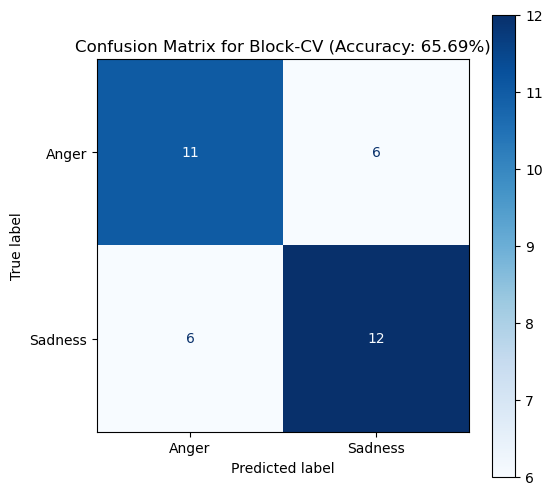

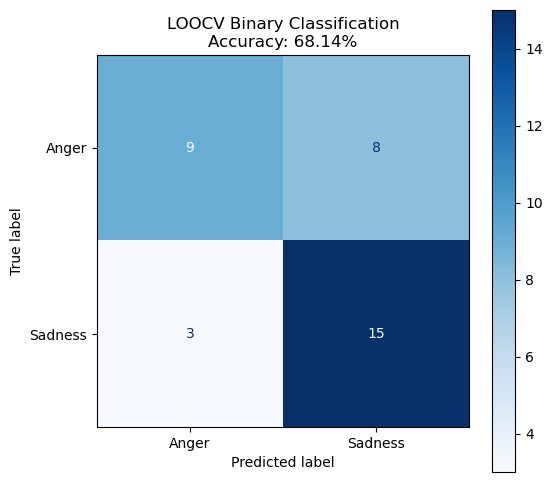

In [101]:
# df = pd.DataFrame(all_emotion_data)
df = df_scaled
# Ensure column order matches for both training and plotting
features = ['VSA', 'ComEDA', 'HR'] 
X = df[features].values
y = df['Emotion'].values
groups = df['Block'].values 
clf = make_pipeline(
    # StandardScaler(), 
    SVC(
        kernel='linear', 
        C=0.05, gamma='auto', class_weight='balanced')
)

# 3d Plot
clf.fit(X, y) # Fit on all data for the 3D visualization
n_sv = clf.named_steps['svc'].support_.size
support_vector_ratio = n_sv / len(X)
fig_3d = px.scatter_3d(
    df, 
    x='HR', y='ComEDA', z='VSA',
    color='Emotion',
    symbol='Block',
    opacity=0.7,
    title=f'Subject-Dependent SVC (Support Vector Ratio: {support_vector_ratio:.2%})'
)
# Hyperplane
N = 50
x_range = np.linspace(df['HR'].min(), df['HR'].max(), N)
y_range = np.linspace(df['ComEDA'].min(), df['ComEDA'].max(), N)
z_range = np.linspace(df['VSA'].min(), df['VSA'].max(), N)
xx, yy, zz = np.meshgrid(x_range, y_range, z_range)
grid_df = pd.DataFrame({
    'VSA': zz.ravel(),  # Mapping zz to VSA
    'ComEDA': yy.ravel(),  # Mapping yy to T_2
    'HR': xx.ravel()    # Mapping xx to HR
})
# Get signed distance to boundary
val = clf.decision_function(grid_df).reshape(xx.shape)
fig_3d.add_trace(go.Isosurface(
    x=xx.flatten(), 
    y=yy.flatten(), 
    z=zz.flatten(), 
    value=val.flatten(),
    isomin=-0.1, isomax=0.1, 
    surface_count=2,
    caps=dict(x_show=False, y_show=False, z_show=False),
    opacity=0.4,
    colorscale='RdBu',
    showscale=False,
    name='SVC Decision Boundary'
))
fig_3d.show()

# Perform Block-CV
logo = LeaveOneGroupOut()
y_pred = cross_val_predict(clf, X, y, groups=groups, cv=logo)
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(y, y_pred, cmap='Blues', ax=ax)
plt.title(f'Confusion Matrix for Block-CV (Accuracy: {balanced_accuracy_score(y, y_pred):.2%})')
plt.show()

# Perform LOO-CV
loo = LeaveOneOut()
y_pred = cross_val_predict(clf, X, y, cv=loo)
acc = balanced_accuracy_score(y, y_pred)
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(y, y_pred, cmap='Blues', ax=ax)
plt.title(f'LOOCV Binary Classification\nAccuracy: {acc:.2%}')
plt.show()

c:\Users\Mario Tokumori\.conda\envs\handeln2025\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


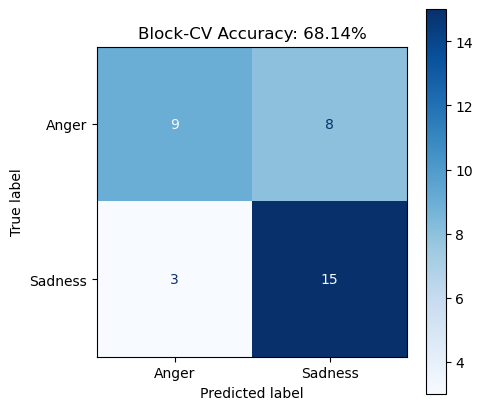

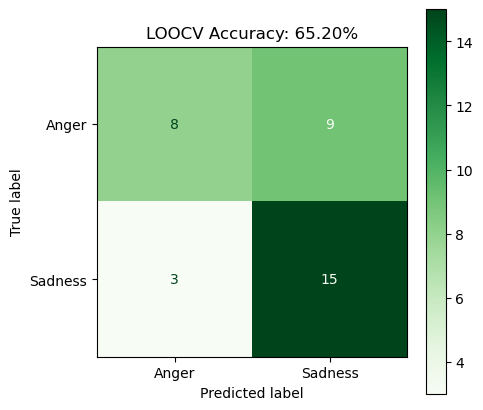

In [102]:
features_2d = ['VSA', 'HR'] 
X = df[features_2d].values
y = df['Emotion'].values
groups = df['Block'].values 

scaler = StandardScaler()

# Scale features per block
X_scaled = np.zeros_like(X)
for block_id in np.unique(groups):
    mask = groups == block_id
    X_scaled[mask] = scaler.fit_transform(X[mask])

clf = make_pipeline(
    # StandardScaler(), 
    SVC(
        kernel='linear', 
        C=0.1, class_weight='balanced')
)

# Fit on all data for visualization
clf.fit(X, y)
n_sv = clf.named_steps['svc'].support_.size
support_vector_ratio = n_sv / len(X)

fig_2d = px.scatter(
    df, 
    x='HR', y='VSA',
    color='Emotion',
    symbol='Block',
    opacity=0.8,
    title=f'2D SVC Decision Boundary (SV Ratio: {support_vector_ratio:.2%})',
    template='plotly_white'
)

N = 100
x_range = np.linspace(df['HR'].min(), df['HR'].max(), N)
y_range = np.linspace(df['VSA'].min(), df['VSA'].max(), N)
xx, yy = np.meshgrid(x_range, y_range)

grid_df = pd.DataFrame({
    'VSA': yy.ravel(), 
    'HR': xx.ravel()
})

Z = clf.decision_function(grid_df).reshape(xx.shape)

fig_2d.add_trace(go.Contour(
    x=x_range,
    y=y_range,
    z=Z,
    showscale=False,
    contours_coloring='none',
    contours=dict(start=0, end=0, size=1), # Only draw the 0 line
    line_width=3,
    line_color='black',
    name='Decision Boundary'
))

fig_2d.show()

logo = LeaveOneGroupOut()
y_pred_block = cross_val_predict(clf, X, y, groups=groups, cv=logo)
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(y, y_pred_block, cmap='Blues', ax=ax)
plt.title(f'Block-CV Accuracy: {balanced_accuracy_score(y, y_pred_block):.2%}')
plt.show()

loo = LeaveOneOut()
y_pred_loo = cross_val_predict(clf, X, y, cv=loo)
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(y, y_pred_loo, cmap='Greens', ax=ax)
plt.title(f'LOOCV Accuracy: {balanced_accuracy_score(y, y_pred_loo):.2%}')
plt.show()